In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r"churn dataset.csv")
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
import io

def about_df(df):
    # Sample view
    df_sample = df.sample(10)
    
    # Get size
    size = df.shape
    
    # Get info (this will print info and not return it, so we capture it separately)
    buffer = io.StringIO()
    df.info(buf=buffer)
    info = buffer.getvalue()
    
    # Get column names and types
    columns = df.dtypes
    
    # Get missing values
    missing_values = df.isnull().sum()
    
    # Get statistics for numerical columns
    stats = df.describe(include='all') # Include 'all' to get stats for non-numerical columns as well
    
    return df_sample, size, info, columns, missing_values, stats


# Get DataFrame information
df_sample, size, info, columns, missing_values, stats = about_df(df)

# Print the results
print('DataFrame Sample:')
print(df_sample)
print('\nDataFrame Size:', size)
print('\nDataFrame Info:')
print(info)
print('\nColumn Names and Types:')
print(columns)
print('\nMissing Values:')
print(missing_values)
print('\nStatistics:')
print(stats)


DataFrame Sample:
       CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
16495       16496   45    Male      40               21              5   
14561       14562   50    Male       9               15              4   
31784       31785   19  Female      42               12              1   
63235       63236   43  Female      53                4              7   
10047       10048   35    Male      44               23              9   
25802       25803   34  Female      37               23              6   
12896       12897   26  Female      37               15              7   
27970       27971   36  Female      48               11              4   
50139       50140   39  Female      31                6              6   
10134       10135   35    Male      11               10              2   

       Payment Delay Subscription Type Contract Length  Total Spend  \
16495              7             Basic         Monthly          736   
14561             21     

In [5]:
def customer_statistics(df):
    # Calculate the relevant statistics
    average_age = df.iloc[:, 1].mean()
    average_tenure = df.iloc[:, 3].mean()
    total_spend = df.iloc[:, 9].sum()
    average_support_calls = df.iloc[:, 5].mean()
    churn_rate = df.iloc[:, 11].mean() * 100
    payment_delay_std_dev = df.iloc[:, 6].std()

    # Create a dictionary to store the statistics
    statistics = {
        'Average Age': average_age,
        'Average Tenure': average_tenure,
        'Total Spend': total_spend,
        'Average Support Calls': average_support_calls,
        'Churn Rate (%)': churn_rate,
        'Payment Delay Std Dev': payment_delay_std_dev
    }
    
    return statistics


In [6]:
stats = customer_statistics(df)

for key, value in stats.items():
    # Check karein agar value numeric hai (float ya int)
    if isinstance(value, (int, float)):
        print(f"{key}: {round(value, 2)}")
    else:
        print(f"{key}: {value}")


Average Age: 41.97
Average Tenure: 31.99
Total Spend: 34827839
Average Support Calls: 5.4
Churn Rate (%): 47.37
Payment Delay Std Dev: 8.85


#Graphs

In [27]:
def future_insights(df):
    

    # projected Total spend for next year assuming similar behaviar
    average_monthly_spend = df.iloc[:,9].mean()
    projected_total_spend_year = average_monthly_spend *12 *len(df)

    #churn Prediction
    churn_rate = df.iloc[:,11].mean()
    projected_churn_next_year = churn_rate * len(df)

    #increase suport calls
    average_support_calls = df.iloc[:,5].mean()
    projected_support_calls_increase = average_support_calls * 1.1

    #predicted delay
    average_payment_delay = df.iloc[:,6].mean()
    projected_payment_delay_increase = average_payment_delay * 1.05

    # subcribtion upgrade
    standard_and_basicd_users = df[(df.iloc[:,7] ==  'Standard') | (df.iloc[:,7] == 'Basic')]
    projected_upgrades = len(standard_and_basicd_users) * 0.15

    #Tuenure Growth
    average_tenure =  df.iloc[:,3].mean()
    project_tenure_growth_year = average_tenure * 1.2

    #create the dictionary to store the future insights

    insights = {
        'Project Total Spend Next year': projected_total_spend_year,
        'Project Churn Next year': projected_churn_next_year,
        'Project Support Calls Increase': projected_support_calls_increase,
        'Project Payment Delay Increase': projected_payment_delay_increase,
        'Project Subscription Upgrade': projected_upgrades,
        'Project Tenure Growth': project_tenure_growth_year
    }

    return insights

future_ints = future_insights(df)

for key, value in future_ints.items():
    print(f"{key}: {round(value,2)}")

Project Total Spend Next year: 417934068.0
Project Churn Next year: 30493.0
Project Support Calls Increase: 5.94
Project Payment Delay Increase: 17.99
Project Subscription Upgrade: 6442.95
Project Tenure Growth: 38.39


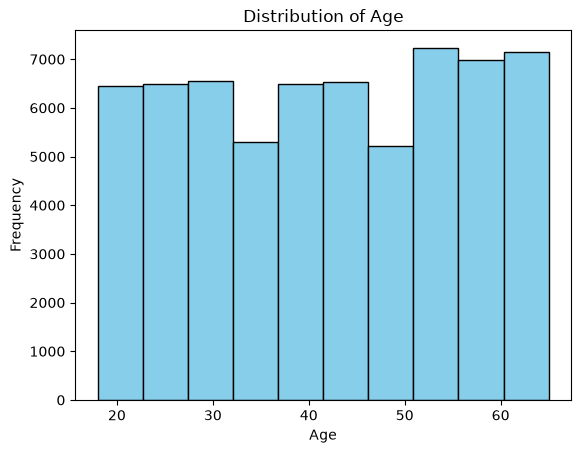

In [38]:
import matplotlib.pyplot as plt

def age_distribution(df):
    df['Age'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
    plt.title("Distribution of Age")
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.show()
    
age_distribution(df)    

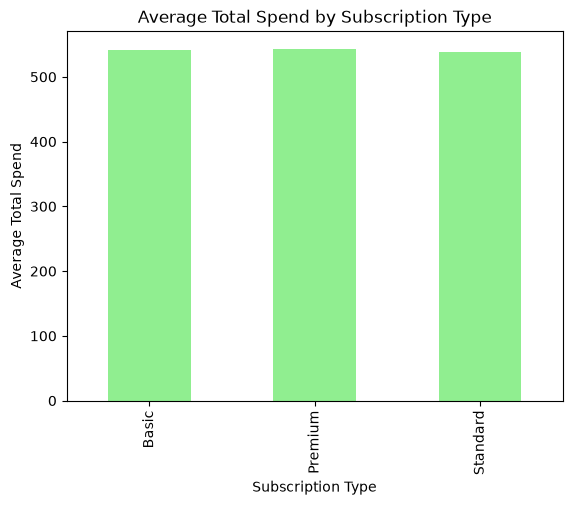

In [47]:
def avg_total_spend_subscription_type(df):
        
    
    df.groupby('Subscription Type')['Total Spend'].mean().plot(kind='bar', color='lightgreen')
    plt.title("Average Total Spend by Subscription Type")
    plt.xlabel('Subscription Type')
    plt.ylabel('Average Total Spend')
    plt.show()
    
avg_total_spend_subscription_type(df)  

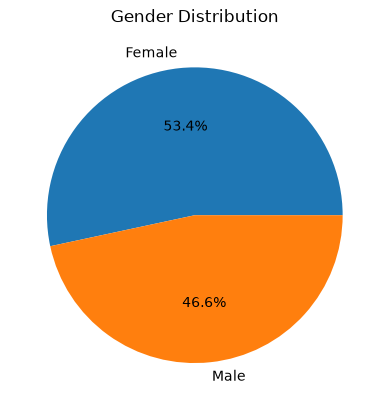

In [66]:
def gender_distribution(df):
        
    
    df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.Figure(figsize=(10,6))
    plt.title("Gender Distribution")
    plt.show()
    
gender_distribution(df)  

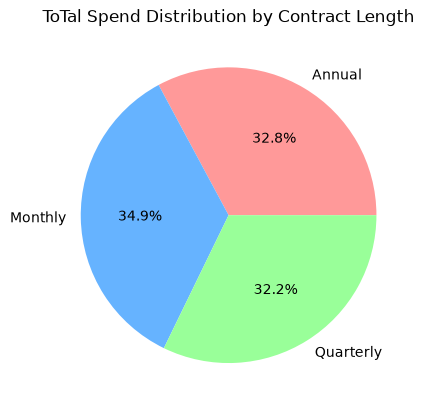

In [70]:
def Distribution_Total_Spend_by_Contract(df):
        
    
    df.groupby('Contract Length')['Total Spend'].sum().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99']
)
    plt.Figure(figsize=(10,8))
    plt.title("ToTal Spend Distribution by Contract Length")
    plt.show()
    
Distribution_Total_Spend_by_Contract(df)  

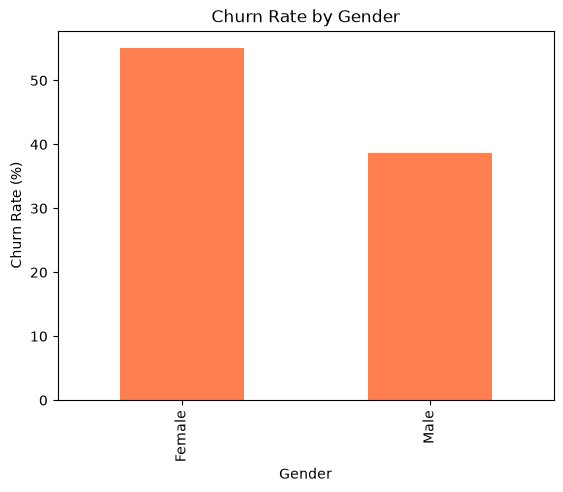

In [71]:
def churn_rate_by_gender(df):
    churn_rate_by_gender = df.groupby('Gender')['Churn'].mean() * 100
    churn_rate_by_gender.plot(kind='bar', color='coral')
    plt.title('Churn Rate by Gender')
    plt.xlabel('Gender')
    plt.ylabel('Churn Rate (%)')
    plt.show()

churn_rate_by_gender(df)


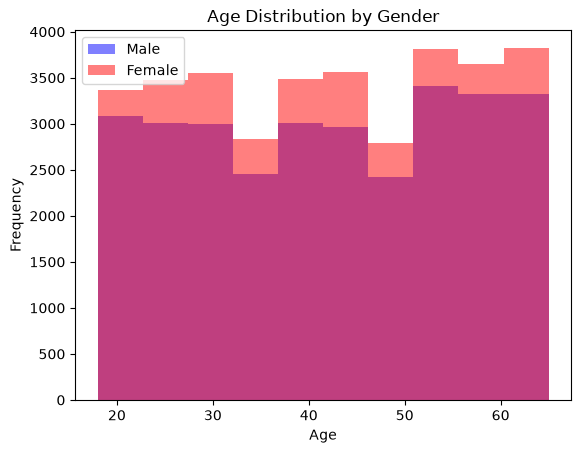

In [72]:
def Age_distribution_by_gender(df):
    df[df['Gender'] == 'Male']['Age'].plot(kind='hist', bins=10, alpha=0.5, color='blue', label='Male')
    df[df['Gender'] == 'Female']['Age'].plot(kind='hist', bins=10, alpha=0.5, color='red', label='Female')
    plt.title('Age Distribution by Gender')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

Age_distribution_by_gender(df)
